<a href="https://colab.research.google.com/github/JorgeEVC/Unimodal-Model-for-Emotion-Detection-in-IVLEs-Using-Spatial-Analysis-of-Hands-and-Head/blob/main/IEEE_Medias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Montaje del drive y R

In [ ]:
%load_ext rpy2.ipython

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Instalación de paquetes y librerias

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.pipeline import Pipeline

In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

In [ ]:
!pip install --quiet optuna
import optuna
from sklearn.model_selection import cross_val_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import classification_report

# Random Forest en Valencia

Del análisis de los componentes que explicaran más del 95% de la varianza, se determinan como variables útiles:

* **R_kx, L_ky, AL_ky**

* opcion adicional **H_Kz, AH_Kz**

Se lee la tabla *_redux_val* en el dataframe *Tabla* y se separan los valores de entrada y salida.

In [ ]:
Tabla=pd.read_excel("/content/drive/MyDrive/Datos V2/Tejalpa_redux_val.xlsx")
x=Tabla.drop(["Val", "ValCat"], axis=1)
y=Tabla["Val"]
x.head()

,R_kx,AL_ky,L_ky
0,-696896.621964,5.341033e+05,4.899477e+05
1,452170.201713,6.610479e+04,-2.991904e+06
2,-22641.046578,8.642867e+05,9.048396e+05
3,899587.553411,2.616209e+06,4.077553e+06
4,3016.529656,-5.723872e+05,-2.914362e+05


In [ ]:
y.head()

,Val
0,0.954308
1,0.954561
2,0.697022
3,0.716641
4,0.723382


Se separan las muestras de entrenamiento y prueba en 80/20.

Se utiliza un Random forest con los metaparametros Default.

En la variable *regressor*  se guarda el modelo entrenado y se prueba con el 20% de x_test.

Al final se obtiene el ECM.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state=0)

In [ ]:
rf_reg = RandomForestRegressor (random_state=42)
regressor = rf_reg.fit(x_train, y_train)
y_pred = regressor.predict(x_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(y_test, y_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(y_test, y_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("Coeficiente de Determinación", metrics.r2_score(y_test, y_pred))

Error Cuadrático Medio 0.051173840740749876
Error Absoluto Medio 0.1762441151591398
Raíz del Error Cuadrático Medio 0.22621635825189537
Coeficiente de Determinación -0.20282058213331933


La primera aproximación con el dataset original con los hyperparámetros en default, arrojan un ECM de 0.0511

## SMOTE en valencia

Para realizar el balanceo de los datos, primero se categorizan los datos de valencia en 1=muy bajo, 2=bajo, 3=medio, 4=alto y 5=muy alto. El *y_smote* recoge la columna de valencia categorizada.

In [ ]:
df_smote=pd.read_excel("/content/drive/MyDrive/Datos V2/Tejalpa_redux_val.xlsx")
x_smote=df_smote.filter(items=["R_kx", "AL_ky", "L_ky", "Val"])
y_smote=df_smote["ValCat"]

print('Original dataset shape %s' % Counter(y_smote))
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(x_smote, y_smote)
print('Resampled dataset shape %s' % Counter(y_res))

Original dataset shape Counter({5: 279, 4: 131, 3: 41, 1: 7, 2: 6})
Resampled dataset shape Counter({5: 279, 4: 279, 3: 279, 2: 279, 1: 279})


El data set para valencia pasa de 464 a 1395 observaciones, abarcando las 5 categorias.

##Random Forest con los datos de SMOTE

In [ ]:
Nx=X_res.drop(["Val"], axis=1)
Ny=X_res["Val"]
Nx_train, Nx_test, Ny_train, Nyv_test = train_test_split(Nx,Ny,test_size=0.20, random_state=0)

In [ ]:
rf_reg2 = RandomForestRegressor (random_state=42)
regressor2 = rf_reg2.fit(Nx_train, Ny_train)
Nyv_pred = regressor2.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.04197406591864003
Error Absoluto Medio 0.1314764548627206
Raíz del Error Cuadrático Medio 0.20487573286907365
Coeficiente de Determinación 0.5635192899594582


En este punto se tiene un modelo en la variable *regressor2* para la variable Valencia entrenada con datos SMOTE. Además puede apreciarse que con dichos datos se obtuvo un ECM menor al original (0.05117 > 0.0419).


In [ ]:
regressor2.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

##Optimización de hyperparametros con GridSearchCV

Ahora se busca mejorar los hyperparametros y refinar el modelo. En esta sección se usa el param_grid y GridSearchCV para generar opciones de combinación y probarlas.

In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [10, 20, 30, 40],
    'max_features': [1, 2, 10, 20],
    'min_samples_leaf': [1, 2, 3, 4],
    'min_samples_split': [2, 5, 7, 10],
    'n_estimators': [30, 50, 100, 300]
}

In [ ]:
rfr_cv = GridSearchCV(estimator = rf_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfr_cv.fit(Nx_train, Ny_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [10, 20, 30, 40],
                         'max_features': [1, 2, 10, 20],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 5, 7, 10],
                         'n_estimators': [30, 50, 100, 300]},
             scoring='neg_mean_squared_error')

In [ ]:
rfr_cv.best_params_

{'bootstrap': True,
 'max_depth': 30,
 'max_features': 2,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [ ]:
Nyv_pred = rfr_cv.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.0398607377346855
Error Absoluto Medio 0.13126705533386882
Raíz del Error Cuadrático Medio 0.19965154077713876
Coeficiente de Determinación 0.5854954070234838


con un ECM 0.04019 > 0.03986, estos parametros no son del todo mejores que el default.

Usando los resultados se define un nuevo param_grid

In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [35, 40, 45, 50],
    'max_features': [9, 10, 11, 12],
    'min_samples_leaf': [2, 3, 4, 5],
    'min_samples_split': [3, 4, 5, 6],
    'n_estimators': [100, 200, 300, 400]
}

In [ ]:
rfr_cv = GridSearchCV(estimator = rf_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfr_cv.fit(Nx_train, Ny_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [35, 40, 45, 50],
                         'max_features': [9, 10, 11, 12],
                         'min_samples_leaf': [2, 3, 4, 5],
                         'min_samples_split': [3, 4, 5, 6],
                         'n_estimators': [100, 200, 300, 400]},
             scoring='neg_mean_squared_error')

In [ ]:
rfr_cv.best_params_

{'bootstrap': True,
 'max_depth': 35,
 'max_features': 9,
 'min_samples_leaf': 2,
 'min_samples_split': 3,
 'n_estimators': 300}

In [ ]:
Nyv_pred = rfr_cv.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.042872066566538164
Error Absoluto Medio 0.1371697144444417
Raíz del Error Cuadrático Medio 0.20705570884797686
Coeficiente de Determinación 0.554181143848686


Con un ECM de 0.0428 los nuevos parametros empeoran la prueba.

In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [15, 20, 25, 30],
    'max_features': [2, 5, 7, 9],
    'min_samples_leaf': [1, 2, 3, 4],
    'min_samples_split': [2, 3, 4, 5],
    'n_estimators': [300, 350, 400, 450]
}

In [ ]:
rfr_cv = GridSearchCV(estimator = rf_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfr_cv.fit(Nx_train, Ny_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [15, 20, 25, 30],
                         'max_features': [2, 5, 7, 9],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4, 5],
                         'n_estimators': [300, 350, 400, 450]},
             scoring='neg_mean_squared_error')

In [ ]:
rfr_cv.best_params_

{'bootstrap': True,
 'max_depth': 30,
 'max_features': 2,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 300}

In [ ]:
Nyv_pred = rfr_cv.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.03965076722034345
Error Absoluto Medio 0.1313302308301026
Raíz del Error Cuadrático Medio 0.19912500400588432
Coeficiente de Determinación 0.5876788523767466


En esta última interación con GRdSearchCV los resultados mejoran (0.0396 < 0.0428).

##Optimización de hyperparametros con Optuna

A continuación se utiliza una aproximación con Optuna para buscar mejores hyperparametros a los encontrados con GridSearchCV.

Se utilizan los resultados anteriores para diseñar el study de optuna y se itera varias veces ajustando los parametros del estudio de acuerdo a los resultados de cada estudio previo. Las celdas siguientes presentan la última iteración.

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 320, 390, step=10)
    max_depth = trial.suggest_int('max_depth', 25, 41, step=2)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 3)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 2)
    max_features = trial.suggest_int('max_features', 2, 3)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features)

    score = cross_val_score(model, Nx_train, Ny_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1).mean()
    return score

In [ ]:
study = optuna.create_study(study_name='Valencia', direction='maximize', sampler=optuna.samplers.RandomSampler(seed=34))

[I 2025-08-08 06:29:21,027] A new study created in memory with name: Valencia


In [ ]:
study.optimize(objective, n_trials=500)

[I 2025-08-08 06:29:35,017] Trial 0 finished with value: -0.04316738290559462 and parameters: {'n_estimators': 320, 'max_depth': 39, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 2}. Best is trial 0 with value: -0.04316738290559462.
[I 2025-08-08 06:29:48,644] Trial 1 finished with value: -0.04170783491806061 and parameters: {'n_estimators': 390, 'max_depth': 31, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 2}. Best is trial 1 with value: -0.04170783491806061.
[I 2025-08-08 06:29:59,271] Trial 2 finished with value: -0.04351153094708214 and parameters: {'n_estimators': 320, 'max_depth': 35, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 3}. Best is trial 1 with value: -0.04170783491806061.
[I 2025-08-08 06:30:11,159] Trial 3 finished with value: -0.04195634071325016 and parameters: {'n_estimators': 380, 'max_depth': 29, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 2}. Best is trial 1 with value: -0.04170783491806061.


In [ ]:
study.best_params

{'n_estimators': 330,
 'max_depth': 37,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 2}

In [ ]:
bestParams = study.best_params

In [ ]:
optuna.visualization.plot_optimization_history(study)

In [ ]:
optuna.visualization.plot_slice(study, params=['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features'])

In [ ]:
best_n_estimators = bestParams['n_estimators']
best_max_depth = bestParams['max_depth']
best_min_samples_split = bestParams['min_samples_split']
best_min_samples_leaf = bestParams['min_samples_leaf']
best_max_features = bestParams['max_features']

In [ ]:
best_model = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    random_state=39)

In [ ]:
best_model.fit(Nx_train, Ny_train)

RandomForestRegressor(max_depth=37, max_features=2, n_estimators=330,
                      random_state=39)

In [ ]:
Nyv_pred = best_model.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.03943322671106187
Error Absoluto Medio 0.13034343081550975
Raíz del Error Cuadrático Medio 0.19857801165048933
Coeficiente de Determinación 0.5899410167364694


## Best hyperparameters

Este ultimo paso explora una sección del espacio solución combinando los parametros señalados. Tras repetir varias veces el procedimiento se obtuvieron los valores utilizados en el siguiente bloque de código como los mejores.

In [ ]:
fix_reg = RandomForestRegressor (n_estimators=330, max_depth=37, min_samples_split=2, min_samples_leaf=1, max_features=2, random_state=39) #ECM 0.03943 CD 0.5899
fix_regressor = fix_reg.fit(Nx_train, Ny_train) #Nombre del modelo: fix_regressor
Nyv_pred = fix_regressor.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.03943322671106187
Error Absoluto Medio 0.13034343081550975
Raíz del Error Cuadrático Medio 0.19857801165048933
Coeficiente de Determinación 0.5899410167364694


# Random Forest de Activacion

Se lee la tabla Tejalpa_redux_Act en el dataframe *Tabla* y se separan los valores de entrada y salida.

In [ ]:
Tabla2=pd.read_excel("/content/drive/MyDrive/Datos V2/Tejalpa_redux_Act.xlsx")
x2=Tabla2.drop(["Act", "ActCat"], axis=1)
y2=Tabla2["Act"]
x2.head()

,R_kx,AL_ky,L_ky
0,-696896.621964,5.341033e+05,4.899477e+05
1,452170.201713,6.610479e+04,-2.991904e+06
2,-22641.046578,8.642867e+05,9.048396e+05
3,899587.553411,2.616209e+06,4.077553e+06
4,3016.529656,-5.723872e+05,-2.914362e+05


In [ ]:
y2.head()

,Act
0,0.958422
1,0.500000
2,0.924485
3,0.698892
4,0.506945


In [ ]:
x2_train, x2_test, y2_train, y2_test = train_test_split(x2,y2,test_size=0.20, random_state=0)

In [ ]:
rf_reg2 = RandomForestRegressor (random_state=42)
regressor2act = rf_reg2.fit(x2_train, y2_train)
y2_pred = regressor2act.predict(x2_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(y2_test, y2_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(y2_test, y2_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(y2_test, y2_pred)))
print("Coeficiente de Determinación", metrics.r2_score(y2_test, y2_pred))

Error Cuadrático Medio 0.05310322601072589
Error Absoluto Medio 0.18996291287311828
Raíz del Error Cuadrático Medio 0.23044137217679878
Coeficiente de Determinación -0.15336272011575636


Se obtienen con el regresor RF default un ECM de 0.053, que es bastante bueno para una primer ronda.

##SMOTE en categoria Activación

Para el SMOTE en Activación se usa de nuevo la tabla Tejalpa_Medias_Full. Esta vez, la variable que se recoge para *y_smote* es la que corresponde a Activación.

In [ ]:
dfa_smote=pd.read_excel("/content/drive/MyDrive/Datos V2/Tejalpa_Medias_Full.xlsx")
xa_smote=dfa_smote.filter(items=["R_kx", "AL_ky", "L_ky", "Act"])
ya_smote=dfa_smote["ActCat"]
print('Original dataset shape %s' % Counter(ya_smote))

sma = SMOTE(random_state=42)
Xa_res, ya_res = sma.fit_resample(xa_smote, ya_smote)
print('Resampled dataset shape %s' % Counter(ya_res))

Original dataset shape Counter({5: 204, 4: 139, 3: 104, 1: 10, 2: 7})
Resampled dataset shape Counter({5: 204, 3: 204, 4: 204, 1: 204, 2: 204})


En este caso con SMOTE se pasa de 464 a 1020 observaciones.

##Random Forest con los datos de SMOTE

In [ ]:
Nxa=Xa_res.drop(["Act"], axis=1)
Nya=Xa_res["Act"]
Nxa_train, Nxa_test, Nya_train, Nya_test = train_test_split(Nxa,Nya,test_size=0.20, random_state=0)

In [ ]:
rfa_reg2 = RandomForestRegressor (random_state=42)
regressor2act = rfa_reg2.fit(Nxa_train, Nya_train)
Nya_pred = regressor2act.predict(Nxa_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.05402903413518577
Error Absoluto Medio 0.16569933217906957
Raíz del Error Cuadrático Medio 0.23244146388969797
Coeficiente de Determinación 0.39606556893532396


En este caso el uso de SMOTE empeora ligeramente el ECM 0.0540 > 0.0531.

In [ ]:
regressor2act.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

##Optimización de hyperparametros con GridSearchCV

In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [10, 20, 30, 40],
    'max_features': [1, 2, 10, 20],
    'min_samples_leaf': [1, 2, 3, 4],
    'min_samples_split': [2, 5, 7, 10],
    'n_estimators': [30, 50, 100, 300]
}

In [ ]:
rfra_cv = GridSearchCV(estimator = rfa_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfra_cv.fit(Nxa_train, Nya_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [10, 20, 30, 40],
                         'max_features': [1, 2, 10, 20],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 5, 7, 10],
                         'n_estimators': [30, 50, 100, 300]},
             scoring='neg_mean_squared_error')

In [ ]:
rfra_cv.best_params_

{'bootstrap': True,
 'max_depth': 20,
 'max_features': 1,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [ ]:
Nya_pred = rfra_cv.predict(Nxa_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.05369761219843122
Error Absoluto Medio 0.1678108769674379
Raíz del Error Cuadrático Medio 0.2317274524056898
Coeficiente de Determinación 0.3997701903859944


In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [10, 30, 40, 50],
    'max_features': [2, 3, 5, 7],
    'min_samples_leaf': [2, 3, 4, 5],
    'min_samples_split': [3, 5, 7, 10],
    'n_estimators': [250, 300, 350, 400]
}

In [ ]:
rfra_cv = GridSearchCV(estimator = rfa_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfra_cv.fit(Nxa_train, Nya_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [10, 30, 40, 50],
                         'max_features': [2, 3, 5, 7],
                         'min_samples_leaf': [2, 3, 4, 5],
                         'min_samples_split': [3, 5, 7, 10],
                         'n_estimators': [250, 300, 350, 400]},
             scoring='neg_mean_squared_error')

In [ ]:
rfra_cv.best_params_

{'bootstrap': True,
 'max_depth': 30,
 'max_features': 2,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 350}

In [ ]:
Nya_pred = rfra_cv.predict(Nxa_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.055721240349541554
Error Absoluto Medio 0.17429475931867427
Raíz del Error Cuadrático Medio 0.236053469259703
Coeficiente de Determinación 0.3771501540353652


Los resultados de esta segunda prueba son menos favorables (0.0557 > 0.536).

##Optimización de hyperparametros con Optuna

Utilizando los resultados anteriores se diseña el study de optuna. En el caso de la variable activación el elemento más importante parece ser la cantidad de estimadores.

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 340, 400, step=10)
    max_depth = trial.suggest_int('max_depth', 30, 70, step=4)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 2)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 1)
    max_features = trial.suggest_int('max_features', 1, 1)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features)

    score = cross_val_score(model, Nxa_train, Nya_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1).mean()
    return score

In [ ]:
studyact = optuna.create_study(study_name='Activacion', direction='maximize', sampler=optuna.samplers.RandomSampler(seed=1))

[I 2025-08-11 00:05:11,562] A new study created in memory with name: Activacion


In [ ]:
studyact.optimize(objective, n_trials=500)

[I 2025-08-11 00:05:23,729] Trial 0 finished with value: -0.05189350206328408 and parameters: {'n_estimators': 360, 'max_depth': 58, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1}. Best is trial 0 with value: -0.05189350206328408.
[I 2025-08-11 00:05:29,855] Trial 1 finished with value: -0.05164732196452569 and parameters: {'n_estimators': 340, 'max_depth': 42, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1}. Best is trial 1 with value: -0.05164732196452569.
[I 2025-08-11 00:05:38,072] Trial 2 finished with value: -0.05189940695359389 and parameters: {'n_estimators': 350, 'max_depth': 34, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1}. Best is trial 1 with value: -0.05164732196452569.
[I 2025-08-11 00:05:44,343] Trial 3 finished with value: -0.05169802760138305 and parameters: {'n_estimators': 350, 'max_depth': 42, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1}. Best is trial 1 with value: -0.05164732196452569.


In [ ]:
studyact.best_params

{'n_estimators': 380,
 'max_depth': 50,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 1}

In [ ]:
bestParamsact = studyact.best_params

In [ ]:
optuna.visualization.plot_optimization_history(studyact)

In [ ]:
optuna.visualization.plot_slice(studyact, params=['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features'])

In [ ]:
actbest_n_estimators = bestParamsact['n_estimators']
actbest_max_depth = bestParamsact['max_depth']
actbest_min_samples_split = bestParamsact['min_samples_split']
actbest_min_samples_leaf = bestParamsact['min_samples_leaf']
actbest_max_features = bestParamsact['max_features']

In [ ]:
best_modelact = RandomForestRegressor(
    n_estimators=actbest_n_estimators,
    max_depth=actbest_max_depth,
    min_samples_split=actbest_min_samples_split,
    min_samples_leaf=actbest_min_samples_leaf,
    max_features=actbest_max_features,
    random_state=39)

In [ ]:
best_modelact.fit(Nxa_train, Nya_train)

RandomForestRegressor(max_depth=50, max_features=1, n_estimators=380,
                      random_state=39)

In [ ]:
Nya_pred = best_modelact.predict(Nxa_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.053382952011034664
Error Absoluto Medio 0.16782157284905394
Raíz del Error Cuadrático Medio 0.23104751028962564
Coeficiente de Determinación 0.403287449657714


## Best Hyperparameters

Se obtuvieron los valores utilizados en el siguiente bloque de código como los mejores.

In [ ]:
fix_regact = RandomForestRegressor (n_estimators=380, max_depth=50, min_samples_split=2, min_samples_leaf=1, max_features=1, random_state=42) #ECM 0.052401   CD 0.41425
fix_regressoract = fix_regact.fit(Nxa_train, Nya_train)
Nya_pred = fix_regressoract.predict(Nxa_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.05240172779587402
Error Absoluto Medio 0.16556246165003588
Raíz del Error Cuadrático Medio 0.22891423676974315
Coeficiente de Determinación 0.4142555355695813


#Prueba con datos aleatorios del dataset original

In [ ]:
TejaSamp = Tabla.sample(frac=0.10, random_state=42)
xSamp=TejaSamp.drop(["Val", "ValCat"], axis=1)
ySamp=TejaSamp["Val"]
xSamp.head()

,R_kx,AL_ky,L_ky
9,1.177917e+06,1.031920e+05,3.514812e+05
30,3.733571e+05,3.776885e+06,8.691299e+06
39,-1.499707e+05,-5.248049e+05,8.038485e+06
443,1.753924e+06,-8.914405e+05,8.367247e+05
266,3.345689e+04,-3.288978e+06,-7.987644e+06


In [ ]:
ySamp.head()


,Val
9,0.853366
30,0.500000
39,0.913201
443,0.716706
266,0.500000


In [ ]:
YSamp_pred = fix_regressor.predict(xSamp) # se usa el modelo fix_regressor

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(ySamp, YSamp_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(ySamp, YSamp_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(ySamp, YSamp_pred)))
print("Coeficiente de Determinación", metrics.r2_score(ySamp, YSamp_pred))

Error Cuadrático Medio 0.017241179663572262
Error Absoluto Medio 0.09661392913259925
Raíz del Error Cuadrático Medio 0.1313056726252612
Coeficiente de Determinación 0.6894461002428409


In [ ]:
DfValSamp = pd.DataFrame({'PredVal':YSamp_pred, 'RealVal':ySamp})
DfValSamp.head()

,PredVal,RealVal
9,0.853717,0.853366
30,0.500010,0.500000
39,0.774923,0.913201
443,0.772193,0.716706
266,0.524584,0.500000


In [ ]:
TejaSamp2 = Tabla2.loc[TejaSamp.index]
xActSamp=TejaSamp2.drop(["Act", "ActCat"], axis=1)
yActSamp=TejaSamp2["Act"]
xActSamp.head()

,R_kx,AL_ky,L_ky
9,1.177917e+06,1.031920e+05,3.514812e+05
30,3.733571e+05,3.776885e+06,8.691299e+06
39,-1.499707e+05,-5.248049e+05,8.038485e+06
443,1.753924e+06,-8.914405e+05,8.367247e+05
266,3.345689e+04,-3.288978e+06,-7.987644e+06


In [ ]:
yActSamp.head()

,Act
9,0.711552
30,0.500000
39,1.000000
443,0.736100
266,0.500000


In [ ]:
yActSamp_pred = fix_regressoract.predict(xActSamp)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(yActSamp, yActSamp_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(yActSamp, yActSamp_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(yActSamp, yActSamp_pred)))
print("Coeficiente de Determinación", metrics.r2_score(yActSamp, yActSamp_pred))

Error Cuadrático Medio 0.018882147637950188
Error Absoluto Medio 0.10237412179436331
Raíz del Error Cuadrático Medio 0.137412327096044
Coeficiente de Determinación 0.5864301393951826


In [ ]:
DfActSamp = pd.DataFrame({'PredAct':yActSamp_pred, 'RealAct':yActSamp})
DfActSamp.head()

,PredAct,RealAct
9,0.681883,0.711552
30,0.450331,0.500000
39,0.837903,1.000000
443,0.641552,0.736100
266,0.714761,0.500000


In [ ]:
DfSamp_Valores = pd.DataFrame()
DfSamp_Valores = DfValSamp.join(DfActSamp)
DfSamp_Valores.head()

,PredVal,RealVal,PredAct,RealAct
9,0.853717,0.853366,0.681883,0.711552
30,0.500010,0.500000,0.450331,0.500000
39,0.774923,0.913201,0.837903,1.000000
443,0.772193,0.716706,0.641552,0.736100
266,0.524584,0.500000,0.714761,0.500000


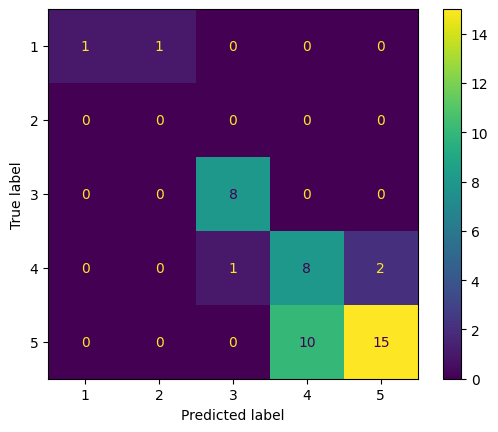

In [ ]:
dfSamp_Val_Real = DfValSamp ['RealVal']
dfSamp_Val_Pred = DfValSamp ['PredVal']

MCVActual_Samp = pd.DataFrame(columns=['Categ'], index=dfSamp_Val_Real.index) # Inicializar con el mismo indice
for index, x in dfSamp_Val_Real.items(): # Iterar en el indice y valor
  if x >=0 and x < 0.2:
    MCVActual_Samp.loc[index, 'Categ'] = 1
  elif x >= 0.2 and x < 0.4:
    MCVActual_Samp.loc[index, 'Categ'] = 2
  elif x >= 0.4 and x < 0.6:
    MCVActual_Samp.loc[index, 'Categ'] = 3
  elif x >= 0.6 and x < 0.8:
    MCVActual_Samp.loc[index, 'Categ'] = 4
  elif x >= 0.8 and x <= 1:
    MCVActual_Samp.loc[index, 'Categ'] = 5

# Convertir la columna a entero despues de poblarla
MCVActual_Samp['Categ'] = MCVActual_Samp['Categ'].astype(int)

MCVPred_Samp = pd.DataFrame(columns=['Categ'], index=dfSamp_Val_Pred.index)
for index, x in dfSamp_Val_Pred.items():
  if x >=0 and x < 0.2:
    MCVPred_Samp.loc[index, 'Categ'] = 1
  elif x >= 0.2 and x < 0.4:
    MCVPred_Samp.loc[index, 'Categ'] = 2
  elif x >= 0.4 and x < 0.6:
    MCVPred_Samp.loc[index, 'Categ'] = 3
  elif x >= 0.6 and x < 0.8:
    MCVPred_Samp.loc[index, 'Categ'] = 4
  elif x >= 0.8 and x <= 1:
    MCVPred_Samp.loc[index, 'Categ'] = 5

MCVPred_Samp['Categ'] = MCVPred_Samp['Categ'].astype(int)

# MCVActual_Samp y MCVPred_Samp deben tener el mismo número de filas que DfVal
Vconfusion_matrix = metrics.confusion_matrix(MCVActual_Samp['Categ'], MCVPred_Samp['Categ'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = Vconfusion_matrix, display_labels = [1,2,3,4,5])

cm_display.plot()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("\nReporte de clasificación:")
print(classification_report(MCVActual_Samp['Categ'], MCVPred_Samp['Categ'],zero_division=0))


Reporte de clasificación:
              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       0.00      0.00      0.00         0
           3       0.89      1.00      0.94         8
           4       0.44      0.73      0.55        11
           5       0.88      0.60      0.71        25

    accuracy                           0.70        46
   macro avg       0.64      0.57      0.57        46
weighted avg       0.78      0.70      0.71        46



In [ ]:
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(MCVActual_Samp['Categ'], MCVPred_Samp['Categ'])
print("Cohen's Kappa:", kappa)

Cohen's Kappa: 0.5461592670894997


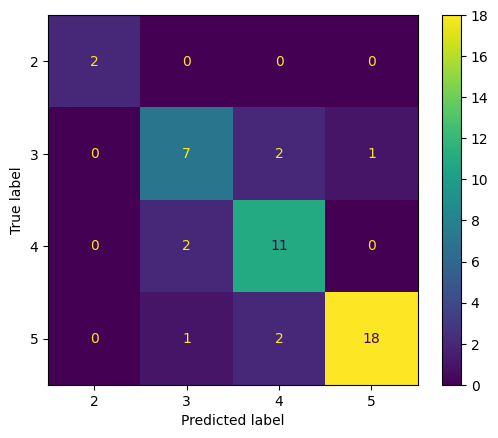

In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt

dfSamp_Act_Real = DfActSamp ['RealAct']
dfSamp_Act_Pred = DfActSamp ['PredAct']

MCActual_Samp = pd.DataFrame(columns=['Categ'], index=dfSamp_Act_Real.index) # Initialize with the same index
for index, x in dfSamp_Act_Real.items(): # Iterate through index and value
  if x >=0 and x < 0.2:
    MCActual_Samp.loc[index, 'Categ'] = 1
  elif x >= 0.2 and x < 0.4:
    MCActual_Samp.loc[index, 'Categ'] = 2
  elif x >= 0.4 and x < 0.6:
    MCActual_Samp.loc[index, 'Categ'] = 3
  elif x >= 0.6 and x < 0.8:
    MCActual_Samp.loc[index, 'Categ'] = 4
  elif x >= 0.8 and x <= 1:
    MCActual_Samp.loc[index, 'Categ'] = 5

# Convert the column to integer type after population
MCActual_Samp['Categ'] = MCActual_Samp['Categ'].astype(int)

MCPred_Samp = pd.DataFrame(columns=['Categ'], index=dfSamp_Act_Pred.index) # Initialize with the same index
for index, x in dfSamp_Act_Pred.items(): # Iterate through index and value
  if x >=0 and x < 0.2:
    MCPred_Samp.loc[index, 'Categ'] = 1
  elif x >= 0.2 and x < 0.4:
    MCPred_Samp.loc[index, 'Categ'] = 2
  elif x >= 0.4 and x < 0.6:
    MCPred_Samp.loc[index, 'Categ'] = 3
  elif x >= 0.6 and x < 0.8:
    MCPred_Samp.loc[index, 'Categ'] = 4
  elif x >= 0.8 and x <= 1:
    MCPred_Samp.loc[index, 'Categ'] = 5

# Convert the column to integer type after population
MCPred_Samp['Categ'] = MCPred_Samp['Categ'].astype(int)

# Now, both MCActual_Samp and MCPred_Samp should have the same number of rows as the original DfAct
confusion_matrix = metrics.confusion_matrix(MCActual_Samp['Categ'], MCPred_Samp['Categ'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [2,3,4,5]) # Update display labels
#cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix) # Update display labels

cm_display.plot()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("\nReporte de clasificación:")
print(classification_report(MCActual_Samp['Categ'], MCPred_Samp['Categ'],zero_division=0))


Reporte de clasificación:
              precision    recall  f1-score   support

           2       1.00      1.00      1.00         2
           3       0.70      0.70      0.70        10
           4       0.73      0.85      0.79        13
           5       0.95      0.86      0.90        21

    accuracy                           0.83        46
   macro avg       0.85      0.85      0.85        46
weighted avg       0.84      0.83      0.83        46



In [ ]:
kappa = cohen_kappa_score(MCActual_Samp['Categ'], MCPred_Samp['Categ'])
print("Cohen's Kappa:", kappa)

Cohen's Kappa: 0.7404795486600846
